# Run Model Notebook (Clean)

This notebook runs a single-country simulation end-to-end and provides a compact analysis workflow.

## How To Use
1. Update parameters in **Inputs**.
2. Run all cells from top to bottom.
3. Review validation summaries and plots.

## Prerequisites
- Environment with project dependencies installed.
- Data available at `data/hfcs/raw` (or set `RAW_DATA_PATH`).


## Sections
- Setup
- Inputs
- Data Preparation
- Country Configuration
- Run Simulation
- Outputs And Plots
- National Accounts Comparison
- Optional Scenario Comparison


In [1]:
# Setup
%load_ext autoreload
%autoreload 2

import logging
import os
import random
from pathlib import Path
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import Config
from macro_data import DataWrapper
from macro_data.configuration import DataConfiguration, split_country_configs
from macro_data.configuration_utils import default_data_configuration, read_country_conf
from macromodel.configurations import CountryConfiguration, SimulationConfiguration
from macromodel.simulation import Simulation
from macromodel.util.loader import Loader
from src.helpers import align_country_configuration_to_data, unpack_cell
from src.visual_helpers import build_macro_output_df, plot_output

logging.getLogger().setLevel(logging.ERROR)


In [2]:
# Inputs
seed = 24 # 32
t_max = 50

# Optional overrides (None means use Config/default env values)
seed_override = seed
country_override = None
raw_data_path_override = None
output_dir_override = None
t_max_override = t_max

cfg = Config().from_env()
if country_override is not None:
    cfg.country_iso3 = country_override
if t_max_override is not None:
    cfg.t_max = t_max_override
if seed_override is not None:
    cfg.seed = seed

random.seed(cfg.seed)

raw_data_path = Path(raw_data_path_override) if raw_data_path_override else (cfg.raw_data_path or Path('data/hfcs/raw'))
output_dir = Path(output_dir_override) if output_dir_override else (cfg.output_path or Path('data/output'))
output_dir.mkdir(parents=True, exist_ok=True)

data_pkl_path = output_dir / 'data.pkl'
model_h5_path = output_dir / 'multi_country_simulation.h5'

print({'seed': cfg.seed, 'country': cfg.country_iso3, 't_max': cfg.t_max, 'raw_data_path': str(raw_data_path), 'output_dir': str(output_dir)})


{'seed': 24, 'country': 'FRA', 't_max': 50, 'raw_data_path': '/Users/andone/Documents/python_projects/macro-main/run_model/data/raw_data', 'output_dir': '/Users/andone/Documents/python_projects/macro-main/run_model/data/output_data'}


In [3]:
# Data Preparation
assert raw_data_path.exists(), f'Raw data path not found: {raw_data_path}'

# Load data configuration
with open(f"{cfg.config_dir}/data_config_FRA.yaml", "r") as f:
    data_config = yaml.safe_load(f)
data_config["country_configs"] = split_country_configs(data_config["country_configs"])
data_config = DataConfiguration(**data_config)

#  Create country data
creator = DataWrapper.from_config(
    configuration=data_config,
    raw_data_path=raw_data_path,
    single_hfcs_survey=False,
)
creator.save(str(data_pkl_path))
data = DataWrapper.init_from_pickle(str(data_pkl_path))

synthetic_country = creator.synthetic_countries[cfg.country_iso3]
na = synthetic_country.exogenous_data.national_accounts

In [4]:
# Load country configuration
with open(f"{cfg.config_dir}/country_config_FRA.yaml", "r") as f:
    country_config_dict = yaml.safe_load(f)
country_cfg = CountryConfiguration(**country_config_dict[cfg.country_iso3])
with open(f"{cfg.config_dir}/country_config_FRA.yaml", "r") as f:
    country_config_dict = yaml.safe_load(f)
country_cfg = CountryConfiguration(**country_config_dict[cfg.country_iso3])

if "data" not in globals():
    data = DataWrapper.init_from_pickle(str(data_pkl_path))


country_cfg = align_country_configuration_to_data(country_cfg, n_industries=data.n_industries)
country_configurations = {cfg.country_iso3: country_cfg}
country_configurations = {cfg.country_iso3: country_cfg}

# Modify loaded country config
country_cfg = country_configurations[cfg.country_iso3]
country_cfg.firms.functions.productivity_growth.name = 'SimpleTFPGrowth'  #'NoOpTFPGrowth'
country_cfg.labour_market.functions.clearing.name = 'PolednaLabourMarketClearer'
country_cfg.central_bank.functions.policy_rate.name = 'SmoothTaylorRule'
country_cfg.government_entities.functions.consumption.name = 'AutoregressiveGovernmentConsumptionSetter'
country_cfg.central_government.functions.social_benefits.name = 'ConstantSocialBenefitsSetter'

# "AutoregressiveGovernmentConsumptionSetter",
# "ConstantGrowthGovernmentConsumptionSetter",
# "ExogenousGovernmentConsumptionSetter"

# # Labour market and policy
# country_cfg.labour_market.functions.clearing.parameters['hiring_speed'] = 0.9
# country_cfg.labour_market.functions.clearing.parameters['firing_speed'] = 0.9
# country_cfg.labour_market.functions.clearing.parameters['random_firing_probability'] = 0.01
# country_cfg.labour_market.functions.clearing.parameters['individuals_quitting'] = True
# country_cfg.labour_market.functions.clearing.parameters['individuals_quitting_temperature'] = 0.3
# country_cfg.labour_market.functions.clearing.parameters['compare_with_normalised_inputs'] = True
# country_cfg.labour_market.functions.clearing.parameters['firing_cost_fraction'] = 0.05
# country_cfg.labour_market.functions.clearing.parameters['hiring_cost_fraction'] = 0.02

print('Configuration summary')
print({'productivity_growth': country_cfg.firms.functions.productivity_growth.name,
       'labour_market_clearer': country_cfg.labour_market.functions.clearing.name,
       'policy_rate_rule': country_cfg.central_bank.functions.policy_rate.name,
       'benefit_rule': country_cfg.central_government.functions.social_benefits.name
       }
       )


Configuration summary
{'productivity_growth': 'SimpleTFPGrowth', 'labour_market_clearer': 'PolednaLabourMarketClearer', 'policy_rate_rule': 'SmoothTaylorRule', 'benefit_rule': 'ConstantSocialBenefitsSetter'}


### Run single simulation

In [5]:
# Run single Simulation

seed = cfg.seed
seed = 15
configuration = SimulationConfiguration(
    country_configurations=country_configurations,
    t_max=cfg.t_max,
    seed=seed,
)

model = Simulation.from_datawrapper(
    datawrapper=data,
    simulation_configuration=configuration,
)

import warnings
warnings.simplefilter("always", RuntimeWarning)

model.run()
model.save(save_dir=output_dir, file_name=model_h5_path.name)

print(f'Simulation complete. Output saved to: {model_h5_path}')

df_base = build_macro_output_df(model, country_code=cfg.country_iso3)




Simulation complete. Output saved to: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/multi_country_simulation.h5


In [6]:
# Outputs And Plots
plot_columns = [
    'total consumption to gdp', 'investment to gdp', 'net exports to gdp',
    'debt to gdp', 'fiscal revenue to gdp', 'fiscal expenditure to gdp', 'deficit to gdp',
    'household consumption to gdp', 'government consumption to gdp', 'gdp', 'real gdp',
    'gdp growth', 'unemployment rate', 'central bank policy rate', 
    'wages', 'profits', 'cpi', 'ppi', 'cpi yoy inflation',
    'taxes paid on production', 'taxes on products', 'government consumption',
    # 'Imports', 'Exports',
    'consumption expansion loan debt', 'mortgage debt',
]

n_rows = 6
n_cols = 4
#  Plot main variables
plot_output(
    df=df_base[plot_columns],
    no_rows=n_rows,
    no_cols=n_cols,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    base_height=200,
    base_width=400,
)

In [10]:
fiscal_cols = [
    'unemployment benefits', 'other benefits', 'government consumption', 'interest payments on debt',
    'unemp_benefits_to_expenditure', 'other_benefits_to_expenditure', 'gov_consumption_to_expenditure', 'interest_payments_on_debt_to_expenditure', 
    'unemployment rate', 'cpi', 'debt to gdp', 'central bank policy rate', 'gdp', 'debt', 'fiscal expenditure', 'deficit', 'gdp growth',
    ]


#  Plot fiscal variables
plot_output(
    df=df_base[fiscal_cols],
    no_rows=5,
    no_cols=4,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    base_height=200,
    base_width=400,
)

In [8]:
cols = [ 
    'unemployment rate', 'cpi yoy inflation',
    'central bank policy rate', 'short-term firm borrowing rate', 'long-term firm borrowing rate',
    'household consumption borrowing rate', 'mortgage borrowing rate'
    ]


#  Plot interest variables
plot_output(
    df=df_base[cols],
    no_rows=3,
    no_cols=3,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    base_height=200,
    base_width=400,
)

<Axes: >

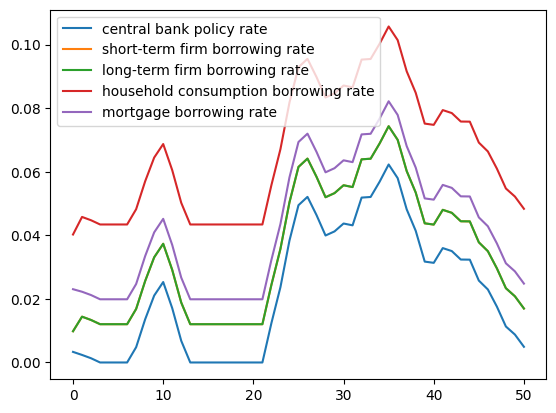

In [9]:
df_base[[
    'central bank policy rate',
    'short-term firm borrowing rate',
    'long-term firm borrowing rate',
    'household consumption borrowing rate',
    'mortgage borrowing rate'
        ]].plot()

<Axes: >

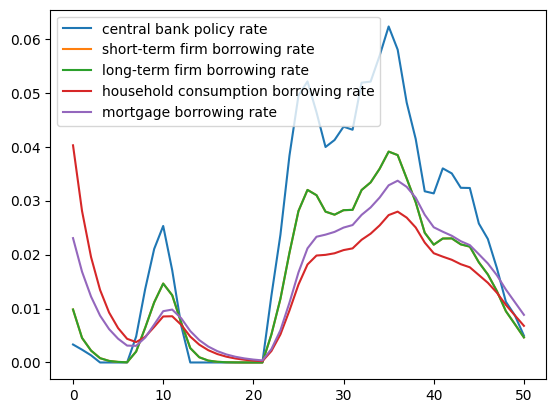

In [16]:
df_base[[
    'central bank policy rate',
    'short-term firm borrowing rate',
    'long-term firm borrowing rate',
    'household consumption borrowing rate',
    'mortgage borrowing rate'
        ]].plot()

### Benchmark comparison

In [ ]:
run_benchmark = True
force_rerun_benchmark = True

if run_benchmark:
    output_dir = cfg.output_path or Path("data/output")
    output_dir.mkdir(parents=True, exist_ok=True)

    data_pkl_path = output_dir / "data_benchmark.pkl"
    df_benchmark_path = output_dir / f"{cfg.country_iso3}_df_benchmark.pkl"
    benchmark_model_path = output_dir / f"{cfg.country_iso3}_benchmark.h5"

    benchmark_spec = {
        "country_iso3": cfg.country_iso3,
        "seed": seed,
        "t_max": cfg.t_max,
        "time_unit": 3,
        "raw_data_path": str(cfg.raw_data_path or Path("data/hfcs/raw")),
        "single_hfcs_survey": False,
        "n_industries": None,
    }

    use_cached_df = df_benchmark_path.exists() and not force_rerun_benchmark
    use_cached_data = data_pkl_path.exists() and not force_rerun_benchmark

    # Load cached benchmark dataframe if available
    if use_cached_df:
        df_benchmark = pd.read_pickle(df_benchmark_path)

        print(f"Loaded cached benchmark dataframe from: {df_benchmark_path}")
        print("Benchmark spec:")
        print(df_benchmark.attrs.get("benchmark_spec", {}))

    else:
        # Load cached benchmark data if available, otherwise build it once
        if use_cached_data:
            data = DataWrapper.init_from_pickle(str(data_pkl_path))
            print(f"Loaded cached benchmark data from: {data_pkl_path}")
        else:
            # Load data configuration
            with open(f"{cfg.config_dir}/data_config_FRA.yaml", "r") as f:
                data_config = yaml.safe_load(f)
            data_config["country_configs"] = split_country_configs(data_config["country_configs"])
            data_config = DataConfiguration(**data_config)

            # This is the "default" data config, not accounting for the changes in data_config_FRA.yaml 
            # data_config = default_data_configuration(
            #     countries=[cfg.country_iso3],
            #     seed=cfg.seed,
            # )
            # data_config.time_unit = benchmark_spec["time_unit"]

            data = DataWrapper.from_config(
                configuration=data_config,
                raw_data_path=cfg.raw_data_path or Path("data/hfcs/raw"),
                single_hfcs_survey=benchmark_spec["single_hfcs_survey"],
            )
            data.save(str(data_pkl_path))
            print(f"Created benchmark data and saved to: {data_pkl_path}")

        benchmark_spec["n_industries"] = data.n_industries

        with open(f"{cfg.config_dir}/country_config_FRA.yaml", "r") as f:
            country_config_dict = yaml.safe_load(f)
        country_cfg = CountryConfiguration(**country_config_dict[cfg.country_iso3])
        country_cfg = align_country_configuration_to_data(country_cfg, n_industries=data.n_industries)

        # country_cfg.central_government.functions.social_benefits.name = 'GrowthSocialBenefitsSetter'
        # country_cfg.central_government.functions.social_benefits.name = 'DefaultSocialBenefitsSetter'
        country_cfg.central_government.functions.social_benefits.name = 'ConstantSocialBenefitsSetter'
        country_cfg.central_bank.functions.policy_rate.name = 'SmoothTaylorRule'
        # country_cfg.firms.functions.productivity_growth.name = 'NoOpTFPGrowth'
        # country_cfg.labour_market.functions.clearing.name = 'PolednaLabourMarketClearer'
        # country_cfg.central_bank.functions.policy_rate.name = 'PolednaPolicyRate'
        # country_cfg.government_entities.functions.consumption.name = 'ConstantGrowthGovernmentConsumptionSetter'

        print('Configuration summary')
        print({'productivity_growth': country_cfg.firms.functions.productivity_growth.name,
               'labour_market_clearer': country_cfg.labour_market.functions.clearing.name,
               'policy_rate_rule': country_cfg.central_bank.functions.policy_rate.name,
               'benefits_rule':  country_cfg.central_government.functions.social_benefits.name})
        
        country_configurations = {cfg.country_iso3: country_cfg}

        benchmark_configuration = SimulationConfiguration(
            country_configurations=country_configurations,
            t_max=cfg.t_max,
            seed=cfg.seed,
        )

        benchmark_model = Simulation.from_datawrapper(
            datawrapper=data,
            simulation_configuration=benchmark_configuration,
        )
        benchmark_model.run()

        benchmark_model.save(
            save_dir=output_dir,
            file_name=benchmark_model_path.name,
        )

        df_benchmark = build_macro_output_df(
            benchmark_model,
            country_code=cfg.country_iso3,
        )
        df_benchmark.attrs["benchmark_spec"] = benchmark_spec
        df_benchmark.to_pickle(df_benchmark_path)

        print(f"Benchmark complete. Model saved to: {benchmark_model_path}")
        print(f"Benchmark dataframe cached at: {df_benchmark_path}")
        print("Benchmark spec:")
        print(df_benchmark.attrs.get("benchmark_spec", {}))

    # Compare custom scenario output against benchmark
    plot_output(
        df=df_base[plot_columns],
        df_compare=df_benchmark[plot_columns],
        no_rows=n_rows,
        no_cols=n_cols,
        country_code=f"{cfg.country_iso3}: Custom scenario vs Benchmark",
        line_color="#1f77b4",
        compare_line_color="#d62728",
        base_name="custom",
        compare_name="benchmark",
        base_height=300,
        base_width=400,
    )
else:
    print("Set run_benchmark = True to execute the benchmark scenario.")

    
fiscal_cols = [
    'unemployment benefits', 'other benefits', 'government consumption', 'interest payments on debt',
    'unemp_benefits_to_expenditure', 'other_benefits_to_expenditure', 'gov_consumption_to_expenditure', 'interest_payments_on_debt_to_expenditure', 
    'unemployment rate', 'cpi', 'debt to gdp', 'policy_rate', 'gdp', 'debt', 'fiscal expenditure', 'deficit', 'gdp growth',
    ]


plot_output(
    df=df_base[fiscal_cols],
    df_compare=df_benchmark[fiscal_cols],
    no_rows=5,
    no_cols=4,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    base_height=200,
    base_width=400,
)

print(df_base[['unemployment rate', 'real gdp']].corr().round(2))
print(df_benchmark[['unemployment rate', 'real gdp']].corr().round(2))

Created benchmark data and saved to: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/data_benchmark.pkl
Configuration summary
{'productivity_growth': 'SimpleTFPGrowth', 'labour_market_clearer': 'PolednaLabourMarketClearer', 'policy_rate_rule': 'SmoothTaylorRule', 'benefits_rule': 'ConstantSocialBenefitsSetter'}
Benchmark complete. Model saved to: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/FRA_benchmark.h5
Benchmark dataframe cached at: /Users/andone/Documents/python_projects/macro-main/run_model/data/output_data/FRA_df_benchmark.pkl
Benchmark spec:
{'country_iso3': 'FRA', 'seed': 15, 't_max': 50, 'time_unit': 3, 'raw_data_path': '/Users/andone/Documents/python_projects/macro-main/run_model/data/raw_data', 'single_hfcs_survey': False, 'n_industries': 18}


                   unemployment rate  real gdp
unemployment rate               1.00     -0.99
real gdp                       -0.99      1.00
                   unemployment rate  real gdp
unemployment rate               1.00     -0.99
real gdp                       -0.99      1.00


In [16]:
ans = 1.02**0.25 - 1
(1 + ans)**4
print(ans)

0.0049629315732038215


In [25]:
policy_cols = [
    'unemployment rate', 'cpi yoy inflation', 'policy_rate', 'gdp', 'gdp growth', 'output_gap',
    ]


plot_output(
    df=df_base[policy_cols],
    df_compare=df_benchmark[policy_cols],
    no_rows=4,
    no_cols=3,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    base_height=200,
    base_width=400,
)


In [11]:
model.countries['FRA'].central_bank.states

{'targeted_inflation_rate': np.float64(0.02),
 'rho': np.float64(0.9036463687149161),
 'r_star': np.float64(-0.002524376119682606),
 'xi_pi': np.float64(1.5109297963588348),
 'xi_gamma': np.float64(4.047341590089337),
 'phi_pi': np.float64(1.8941834200385674),
 'phi_q': np.float64(0.4737673520342317)}

In [ ]:
# Monte Carlo simulations
from src.monte_carlo import run_seeded_monte_carlo

seeds = [19, 23, 27, 32, 37, 43, 54, 57, 71, 85, 98]
# seeds = [i + 1 for i in range(0,10)]
mc = run_seeded_monte_carlo(datawrapper=data,
                            country_configurations=country_configurations,
                            country_code=cfg.country_iso3,
                            seeds=seeds,
                            t_max=cfg.t_max,
                            )

from src.visual_helpers import plot_mc

mc_columns = [
    'total consumption to gdp', 'investment to gdp', 'net exports to gdp',
    'debt to gdp', 'fiscal revenue to gdp', 'fiscal expenditure to gdp', 'deficit to gdp',
    'household consumption to gdp', 'government consumption to gdp', 'gdp', 'real gdp',
    'gdp growth', 'unemployment rate', 'central bank policy rate', 
    'wages', 'profits', 'cpi', 'ppi',
    'taxes paid on production', 'taxes on products', 'government consumption',
    # 'Imports', 'Exports',
    'consumption expansion loan debt', 'mortgage debt',
]


plot_mc(
    mc=mc,
    cols=mc_columns,
    no_rows=7,
    no_cols=4,
    country_code=cfg.country_iso3,
    base_height=200,
    base_width=400,
    line_opacity=0.5,
    line_width=2
)

fiscal_cols = [
    'unemployment benefits', 'other benefits', 'government consumption', 'interest payments on debt',
    'unemp_benefits_to_expenditure', 'other_benefits_to_expenditure', 'gov_consumption_to_expenditure', 'interest_payments_on_debt_to_expenditure', 
    'unemployment rate', 'cpi', 'debt to gdp', 'policy_rate', 'gdp', 'debt', 'fiscal expenditure', 'deficit', 'gdp growth',
    ]

plot_mc(
    mc=mc,
    cols=fiscal_cols,
    no_rows=7,
    no_cols=4,
    country_code=cfg.country_iso3,
    base_height=200,
    base_width=400,
    line_opacity=0.5,
    line_width=2
)


In [ ]:
#  Sensitivity analysis
from src.sensitivity import run_parameter_sensitivity

param_values = np.linspace(0.01, 0.2, 5).tolist()

res = run_parameter_sensitivity(
    datawrapper=data,
    country_configurations=country_configurations,
    country_code=cfg.country_iso3,
    parameter_path="firms.functions.wage_setter.parameters['labour_market_tightness_markup_scale']",
    parameter_values=param_values,
    seeds=[11,12,13],
    t_max=50,
    n_jobs=-1,
    batch_size=4,
)


In [ ]:
from src.visual_helpers import plot_sensitivity_summary, plot_sensitivity

sens_columns = [
    'total consumption to gdp', 'investment to gdp', 'net exports to gdp',
    'debt to gdp', 'fiscal revenue to gdp', 'fiscal expenditure to gdp', 'deficit to gdp',
    'household consumption to gdp', 'government consumption to gdp', 'gdp',
    'gdp growth', 'unemployment rate', 'central bank policy rate', 
    'wages', 'profits', 'cpi', 'ppi',
    'taxes paid on production', 'taxes on products',  'government consumption',
    # 'Imports', 'Exports',
    # 'Consumption Expansion Loan Debt', 'Mortgage Debt',
]


plot_sensitivity(
    sensitivity=res,
    cols=sens_columns,
    country_code=cfg.country_iso3,
    no_cols=4,
    no_rows=6,
    base_height=200,
    base_width=300,
)


# plot_sensitivity_summary(
#     sensitivity=res,
#     cols=sens_columns,
#     country_code=cfg.country_iso3,
#     band=(0.25, 0.75),
# )


### Benchmark Comparison


### National Accounts Comparison

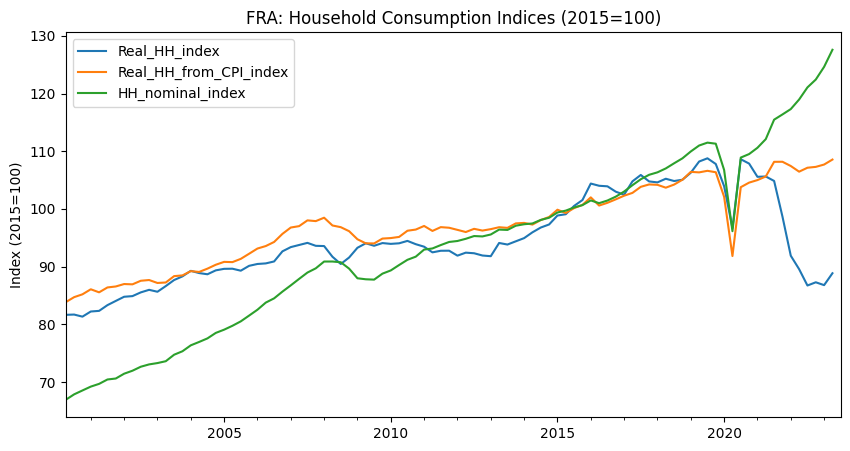

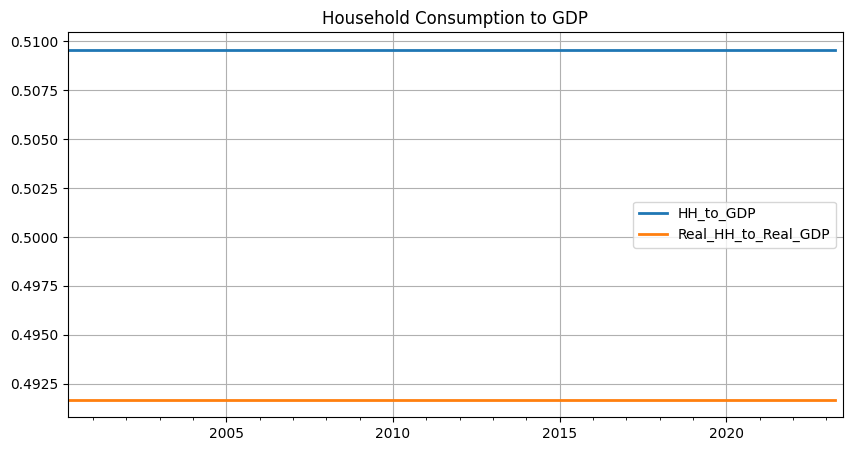

In [9]:
# National Accounts Comparison
na = creator.synthetic_countries[cfg.country_iso3].exogenous_data.national_accounts
ts = pd.DataFrame(index=na.index)

ts['HH_to_GDP'] = na['Household Consumption (Value)'] / na['GDP (Value)']
ts['Real_HH_to_Real_GDP'] = na['Real Household Consumption (Value)'] / na['Real GDP (Value)']
ts['Real_HH_from_CPI'] = na['Household Consumption (Value)'] / na['CPI (Value)']
ts['Real_HH_model'] = na['Real Household Consumption (Value)']
ts['Real_HH_CPI_vs_model_pct_diff'] = (ts['Real_HH_from_CPI'] / ts['Real_HH_model'] - 1.0) * 100.0


def rebase_2015_avg(series: pd.Series) -> pd.Series:
    base = series.loc[series.index.year == 2015].mean()
    return 100.0 * series / base


ts['Real_HH_index'] = rebase_2015_avg(ts['Real_HH_model'])
ts['Real_HH_from_CPI_index'] = rebase_2015_avg(ts['Real_HH_from_CPI'])
ts['HH_nominal_index'] = rebase_2015_avg(na['Household Consumption (Value)'])

ax = ts[['Real_HH_index', 'Real_HH_from_CPI_index', 'HH_nominal_index']].plot(figsize=(10, 5), title=f'{cfg.country_iso3}: Household Consumption Indices (2015=100)')
ax.set_ylabel('Index (2015=100)')
plt.show()

ax = ts[["HH_to_GDP", "Real_HH_to_Real_GDP"]].plot(figsize=(10,5), lw=2, grid=True, title="Household Consumption to GDP")
plt.show()
# ts[['HH_to_GDP', 'Real_HH_to_Real_GDP', 'Real_HH_CPI_vs_model_pct_diff']].tail()


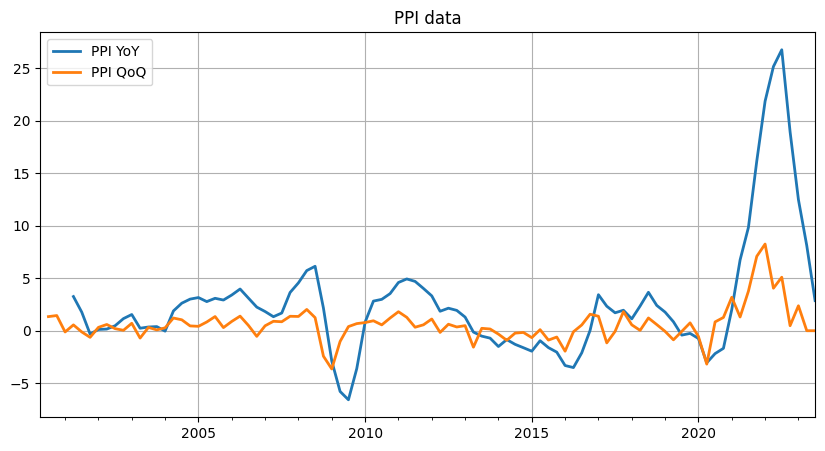

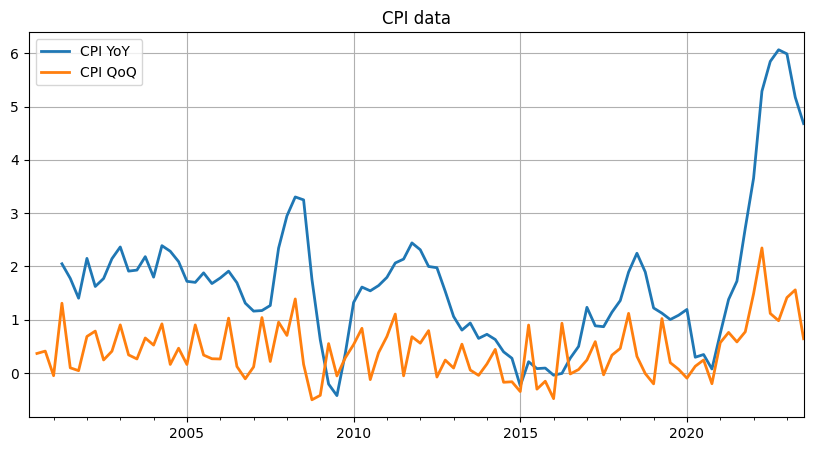

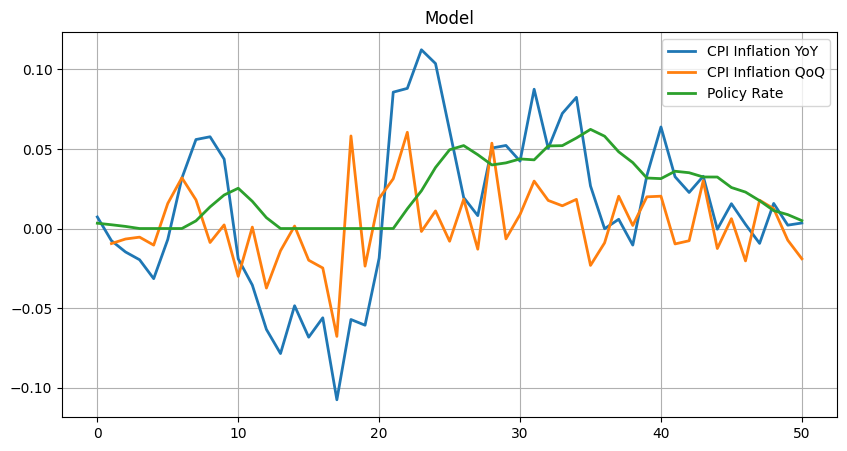

In [26]:
ppi_yoy = na['PPI (Value)'].pct_change(4) * 100.0
ppi_qoq = na['PPI (Value)'].pct_change(1) * 100.0

cpi_yoy = na['CPI (Value)'].pct_change(4) * 100.0
cpi_qoq = na['CPI (Value)'].pct_change(1) * 100.0

fig, ax = plt.subplots(figsize=(10,5))
ax = ppi_yoy.plot(figsize=(10,5), lw=2, grid=True, label="PPI YoY")
ax = ppi_qoq.plot(figsize=(10,5), lw=2, grid=True, label="PPI QoQ")
plt.legend(['PPI YoY', 'PPI QoQ'])
plt.title('PPI data')
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
ax = cpi_yoy.plot(figsize=(10,5), lw=2, grid=True, label="CPI YoY")
ax = cpi_qoq.plot(figsize=(10,5), lw=2, grid=True, label="CPI QoQ")
plt.legend(['CPI YoY', 'CPI QoQ']   )
plt.title('CPI data')
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
ax = df_base['cpi yoy inflation'].plot(figsize=(10,5), lw=2, grid=True, label="CPI Inflation YoY")
ax = df_base['cpi'].pct_change(1).plot(figsize=(10,5), lw=2, grid=True, label="CPI Inflation QoQ")
ax = df_base['central bank policy rate'].plot(figsize=(10,5), lw=2, grid=True, label="Policy Rate")
plt.legend()
plt.title('Model')

plt.show()


In [36]:
model.countries['FRA'].central_bank.states

{'targeted_inflation_rate': np.float64(0.02),
 'rho': np.float64(0.9036463687149161),
 'r_star': np.float64(-0.002524376119682606),
 'xi_pi': np.float64(1.5109297963588348),
 'xi_gamma': np.float64(4.047341590089337),
 'phi_pi': np.float64(1.8941834200385674),
 'phi_q': np.float64(0.4737673520342317)}

# Appendix

### Government consumption behaviour

| Setter | Total-consumption anchor | Growth source | Uses exogenous gov path? | Uses `expected_growth`? | Price adjustment | Sector allocation | Key assumption / caveat |
|---|---|---|---|---|---|---|---|
| `AutoregressiveGovernmentConsumptionSetter` | Forecasted total government consumption `C_t` from AR on historical total consumption | `ManualAutoregForecaster()` on `historic_total_consumption` or `log(historic_total_consumption)` in `macromodel/agents/government_entities/func/consumption.py:171` | No, not directly for the forecast itself; exogenous pre-sample history can be included in `historic_total_consumption` via `macromodel/agents/government_entities/government_entities.py:212` | No | Yes: multiplies by `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:205` | Previous desired spending shares `previous_desired_government_consumption / sum(...)` in `macromodel/agents/government_entities/func/consumption.py:209` | Total is forecasted, but sector shares drift through recursive reweighting with relative prices |
| `ConstantGrowthGovernmentConsumptionSetter` | Previous desired government consumption vector scaled forward each period | Either configured `default_growth`, or estimated once as mean log growth of `historic_total_consumption` in `macromodel/agents/government_entities/func/consumption.py:277` | No | No | Yes: when history exists, uses `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:287` | Implicitly last period’s desired nominal vector, because the whole vector is scaled in `macromodel/agents/government_entities/func/consumption.py:290` | “Constant growth” is literal after initialization; estimated growth is log-growth but later applied as arithmetic growth `(1 + g)`, which is not fully consistent |
| `ExogenousGovernmentConsumptionSetter` | Exogenous total real government consumption path `exogenous_total_consumption[t]` | No endogenous growth estimation; the level comes directly from exogenous national accounts path | Yes: `self.exogenous.national_accounts_during["Real Government Consumption (Value)"]` passed from `macromodel/country/country.py:934` | No | Yes: multiplies by `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:477` | Previous desired spending shares `previous_desired_government_consumption / sum(...)` in `macromodel/agents/government_entities/func/consumption.py:481` | Aggregate path is exogenous, but composition is still endogenous via lagged shares; if exogenous data ends, it raises an error; if exogenous path is missing entirely, it falls back to configured `default_growth` |


### Readers

In [ ]:
from src.helpers import fit_social_benefits_arx_diagnostics
from macro_data.readers.default_readers import DataReaders
from macro_data.readers import AGGREGATED_INDUSTRIES, ALL_INDUSTRIES

country_names = data_config.countries
industries = AGGREGATED_INDUSTRIES if data_config.aggregate_industries else ALL_INDUSTRIES
scale_dict = {country: data_config.country_configs[country].scale for country in country_names}
proxy_country_dict = {
    country: data_config.country_configs[country].eu_proxy_country
    for country in data_config.countries
    if not country.is_eu_country
}

readers = DataReaders.from_raw_data(
    raw_data_path=cfg.raw_data_path,
    country_names=country_names,
    simulation_year=data_config.year,
    scale_dict=scale_dict,
    industries=industries,
    aggregate_industries=data_config.aggregate_industries,
    prune_date=data_config.prune_date,
    force_single_hfcs_survey=False,
    single_icio_survey=True,
    proxy_country_dict=proxy_country_dict,
    use_disagg_can_2014_reader=data_config.can_disaggregation,
    use_provincial_can_reader=False,
    regions_dict=None,
    allow_missing_emissions=False,
)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                  
===========================================================================================
Dep. Variable:     Delta Log Unemployment Benefits   R-squared:                       0.388
Model:                                         OLS   Adj. R-squared:                  0.331
Method:                              Least Squares   F-statistic:                     6.771
Date:                             Thu, 23 Apr 2026   Prob (F-statistic):            0.00115
Time:                                     12:01:27   Log-Likelihood:                 97.206
No. Observations:                               36   AIC:                            -186.4
Df Residuals:                                   32   BIC:                            -180.1
Df Model:                                        3                                         
Covariance Type:                         nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0087      0.005      1.812      0.079      -0.001       0.018
Lagged Inflation       -0.6794      0.929     -0.731      0.470      -2.572       1.213
Unemployment Change     2.8664      1.350      2.124      0.042       0.117       5.616
GDP Growth             -0.8420      0.515     -1.635      0.112      -1.891       0.207
==============================================================================
Omnibus:                        0.290   Durbin-Watson:                   0.622
Prob(Omnibus):                  0.865   Jarque-Bera (JB):                0.374
Skew:                           0.192   Prob(JB):                        0.830
Kurtosis:                       2.680   Cond. No.                         484.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
country_iso3 = cfg.country_iso3   # e.g. "FRA"
year = data_config.year
quarter = data_config.quarter
time_unit = data_config.time_unit  # e.g. 3 for quarterly
periods_per_year = 12 // time_unit
quarter_key = f"{year}-Q{quarter}"


firm_rates_annual = readers.ecb_reader.get_firm_rates(country_iso3)
hh_cons_rates_annual = readers.ecb_reader.get_household_consumption_rates(country_iso3)
hh_mort_rates_annual = readers.ecb_reader.get_household_mortgage_rates(country_iso3)
policy_rates_annual = readers.policy_rates.get_policy_rates(country_iso3)

firm_rates_annual.loc[quarter_key]
hh_cons_rates_annual.loc[quarter_key]
hh_mort_rates_annual.loc[quarter_key]
policy_rates_annual.loc[quarter_key, "Policy Rate"]


2014-01-01    0.0025
Name: Policy Rate, dtype: float64

In [ ]:
country = cfg.country_iso3
quarter_key = f"{2022}-Q{data_config.quarter}"
periods_per_year = 12 // data_config.time_unit

banks = data.synthetic_countries[country].banks

firm_rate_annual = readers.ecb_reader.get_firm_rates(country).loc[quarter_key].iloc[0]
hh_cons_rate_annual = readers.ecb_reader.get_household_consumption_rates(country).loc[quarter_key].iloc[0]
hh_mort_rate_annual = readers.ecb_reader.get_household_mortgage_rates(country).loc[quarter_key].iloc[0]
policy_rate_annual = readers.policy_rates.get_policy_rates(country).loc[quarter_key, "Policy Rate"].iloc[0]

comparison = pd.DataFrame(
    {
        "raw_annual_reader": [
            float(firm_rate_annual),
            float(hh_cons_rate_annual),
            float(hh_mort_rate_annual),
            float(policy_rate_annual),
            float(policy_rate_annual),
        ],
        "expected_per_period": [
            float(firm_rate_annual) / periods_per_year,
            float(hh_cons_rate_annual) / periods_per_year,
            float(hh_mort_rate_annual) / periods_per_year,
            float(policy_rate_annual) / periods_per_year,
            float(policy_rate_annual) / periods_per_year,
        ],
        "stored_in_data": [
            float(banks.firm_rate),
            float(banks.hh_consumption_rate),
            float(banks.hh_mortgage_rate),
            float(banks.bank_data["Interest Rates on Firm Deposits"].iloc[0]),
            float(banks.bank_data["Interest Rates on Household Deposits"].iloc[0]),
        ],
    },
    index=[
        "firm loan rate",
        "hh consumption loan rate",
        "mortgage rate",
        "firm deposit rate",
        "hh deposit rate",
    ],
)

comparison["difference"] = comparison["stored_in_data"] - comparison["expected_per_period"]
comparison


In [13]:
import pandas as pd

country = cfg.country_iso3
quarter_key = f"{data_config.year}-Q{data_config.quarter}"
periods_per_year = 12 // data_config.time_unit

def scalar(x):
    if isinstance(x, pd.DataFrame):
        return x.iloc[0, 0]
    if isinstance(x, pd.Series):
        return x.iloc[0]
    return x

synthetic_country = data.synthetic_countries[country]
banks = synthetic_country.banks
cb_data = synthetic_country.central_bank.central_bank_data

policy_rate_raw_annual = float(scalar(readers.policy_rates.get_policy_rates(country).loc[quarter_key, ["Policy Rate"]]))
firm_loan_raw_annual = float(scalar(readers.ecb_reader.get_firm_rates(country).loc[quarter_key]))
hh_cons_loan_raw_annual = float(scalar(readers.ecb_reader.get_household_consumption_rates(country).loc[quarter_key]))
mortgage_raw_annual = float(scalar(readers.ecb_reader.get_household_mortgage_rates(country).loc[quarter_key]))

rows = [
    ["policy rate from reader", policy_rate_raw_annual, policy_rate_raw_annual / periods_per_year, None],
    ["central bank stored policy_rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(cb_data[["policy_rate"]])) if "policy_rate" in cb_data.columns else None],
    ["central bank stored smooth_policy_rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(cb_data[["smooth_policy_rate"]])) if "smooth_policy_rate" in cb_data.columns else None],
    ["firm deposit rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(banks.bank_data[["Interest Rates on Firm Deposits"]]))],
    ["household deposit rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(banks.bank_data[["Interest Rates on Household Deposits"]]))],
    ["firm loan rate", firm_loan_raw_annual, firm_loan_raw_annual / periods_per_year, float(banks.firm_rate)],
    ["hh consumption loan rate", hh_cons_loan_raw_annual, hh_cons_loan_raw_annual / periods_per_year, float(banks.hh_consumption_rate)],
    ["mortgage rate", mortgage_raw_annual, mortgage_raw_annual / periods_per_year, float(banks.hh_mortgage_rate)],
]

df_rates = pd.DataFrame(rows, columns=["rate", "raw_annual", "expected_per_period", "stored_in_data"])
df_rates["stored_minus_expected"] = df_rates["stored_in_data"] - df_rates["expected_per_period"]

print(f"country={country}, quarter={quarter_key}, time_unit={data_config.time_unit}, periods_per_year={periods_per_year}")
print(df_rates.round(6).to_string(index=False))


country=FRA, quarter=2014-Q1, time_unit=3, periods_per_year=4
                                  rate  raw_annual  expected_per_period  stored_in_data  stored_minus_expected
               policy rate from reader    0.002500             0.000625             NaN                    NaN
       central bank stored policy_rate         NaN             0.000625        0.001878               0.001253
central bank stored smooth_policy_rate         NaN             0.000625        0.000833               0.000208
                     firm deposit rate         NaN             0.000625        0.000625               0.000000
                household deposit rate         NaN             0.000625        0.000625               0.000000
                        firm loan rate    0.022567             0.005642        0.002456              -0.003186
              hh consumption loan rate    0.061133             0.015283        0.010066              -0.005217
                         mortgage rate    0.033167

In [14]:
import pandas as pd

country = cfg.country_iso3
start_period = pd.Period(f"{data_config.year}Q{data_config.quarter}", freq="Q")
init_period = start_period - 1
init_key = f"{init_period.year}-Q{init_period.quarter}"
periods_per_year = 12 // data_config.time_unit

synthetic_country = data.synthetic_countries[country]
cb_data = synthetic_country.central_bank.central_bank_data
banks = synthetic_country.banks

policy_rate_init_annual = float(readers.policy_rates.get_policy_rates(country).loc[init_key, ["Policy Rate"]].iloc[0, 0])
policy_rate_init_period = policy_rate_init_annual / periods_per_year

check = pd.DataFrame(
    [
        ["pre-start policy rate from reader", policy_rate_init_annual, policy_rate_init_period, None],
        ["stored smooth_policy_rate", None, policy_rate_init_period, float(cb_data["smooth_policy_rate"].iloc[0]) if "smooth_policy_rate" in cb_data.columns else None],
        ["stored legacy policy_rate", None, policy_rate_init_period, float(cb_data["policy_rate"].iloc[0]) if "policy_rate" in cb_data.columns else None],
        ["firm deposit rate", None, policy_rate_init_period, float(banks.bank_data["Interest Rates on Firm Deposits"].iloc[0])],
        ["household deposit rate", None, policy_rate_init_period, float(banks.bank_data["Interest Rates on Household Deposits"].iloc[0])],
    ],
    columns=["rate", "raw_annual", "expected_per_period", "stored_in_data"],
)

check["stored_minus_expected"] = check["stored_in_data"] - check["expected_per_period"]
print(f"start={start_period}, init={init_key}, time_unit={data_config.time_unit}")
print(check.round(6).to_string(index=False))


start=2014Q1, init=2013-Q4, time_unit=3
                             rate  raw_annual  expected_per_period  stored_in_data  stored_minus_expected
pre-start policy rate from reader    0.003333             0.000833             NaN                    NaN
        stored smooth_policy_rate         NaN             0.000833        0.000833               0.000000
        stored legacy policy_rate         NaN             0.000833        0.001878               0.001044
                firm deposit rate         NaN             0.000833        0.000625              -0.000208
           household deposit rate         NaN             0.000833        0.000625              -0.000208


# Notes: CBC7

- UK baseline (lots of small edits)
- Synthetic population script mimicking HFCS for the UK. Testing it currently.
- Marcela updated the starting year
- Monte Carlo runs + dashboard
- prehooks for shock
- Marcela tested 1-to-1 simulation


In [ ]:
# CBC7 issues

# UK baseline (lots of small edits)
# Synthetic population script mimicking HFCS for the UK. Testing it currently.
# Marcela updated the starting year
# Monte Carlo runs + dashboard
# prehooks for shock
# Marcela tested 1-to-1 simulation
